In [3]:
import pandas as pd
df = pd.read_csv("../data/507_traditional_dataset.csv")
#specific lable classification
df["LABEL"].unique()

array(['neutral', 'slightly_suspicious', 'suspicious',
       'highly_suspicious', 'legitimate', 'scam',
       'standard_opening, identification_request', 'polite_ending',
       'potential_scam', ' neutral', ' legitimate', ' scam',
       ' scam_response', ' dismissing official protocols"',
       ' emphasizing security and compliance"',
       ' ready for further engagement"',
       ' suggesting a dangerous situation"', 'Scam',
       ' adhering to protocols"', ' citing urgency"', 'scam_response'],
      dtype=object)

In [4]:
#data cleaning(make sure string, remove the space and residual symbols, unify the lowercase)
df["LABEL_CLEAN"] = (df["LABEL"]
    .astype(str)           
    .str.strip()           
    .str.lower()           
    .str.replace('"', ''))  
df["LABEL_CLEAN"].unique()


array(['neutral', 'slightly_suspicious', 'suspicious',
       'highly_suspicious', 'legitimate', 'scam',
       'standard_opening, identification_request', 'polite_ending',
       'potential_scam', 'scam_response', 'dismissing official protocols',
       'emphasizing security and compliance',
       'ready for further engagement', 'suggesting a dangerous situation',
       'adhering to protocols', 'citing urgency'], dtype=object)

In [5]:
#classify(scam vs non-scam)
scam_keywords = [
    "scam",                # scam, potential_scam, scam_response 
    "suspicious",          # slightly_suspicious / highly_suspicious
    "dangerous",           # suggesting a dangerous situation
    "urgency",             # citing urgency
    "dismissing",          # dismissing official protocols
    "compliance",          # emphasizing security and compliance
    "ready for further engagement"]


In [6]:
#mapping fuction
def map_label_to_class(label_clean: str):
    for kw in scam_keywords:
        if kw in label_clean:
            return 1, "traditional_scam"
    return 0, "non_scam"
df[["label_id", "label_text"]] = df["LABEL_CLEAN"].apply(
    lambda x: pd.Series(map_label_to_class(x))
)
df["label_text"].value_counts()

label_text
traditional_scam    397
non_scam            253
Name: count, dtype: int64

In [7]:
#build a standardized training DataFrame
df_std = pd.DataFrame({
    "id": range(len(df)),
    "text": df["TEXT"],             
    "label_id": df["label_id"],
    "label_text": df["label_text"],
    "source": "Kaggle_Call Transcripts Scam Determinations",  
    "is_synthetic": 0})

#new file
output_path = "../data/traditional_calls_standardized.csv"
df_std.to_csv(output_path, index=False)
output_path

'../data/traditional_calls_standardized.csv'

In [8]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    trust_remote_code=True)
model.to("cpu")

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear(in_features=1536, out_features=1536, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (down_proj): Linear(in_features=8960, out_features=1536, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((1536,), eps=1e-06)
    (rotar

In [9]:
def generate_ai_scam_text(scenario: str) -> str:
    """
    Use Qwen2.5-1.5B-Instruct to generate one AI-style scam message.
    Output only the scam message itself.
    """
    prompt = (
    f"Scenario: {scenario}\n"
    "Generate a short scam message spoken by a phone caller.\n"
    "Make it sound like real spoken language: slightly rushed, informal, and a bit hesitant.\n"
    "Avoid email style, avoid paragraphs, avoid HTML, avoid <br>.\n"
    "Do NOT ask for money directly. Instead, talk around the issue and hint at urgency.\n"
    "Use fillers like 'uh', 'listen', 'so', 'I mean', to imitate phone speech.\n"
    "Keep it short: 20–45 words.\n"
    "Use placeholders like <NAME>, <BANK>, <ACCOUNT>.\n"
    "Output ONLY the spoken message.\n"
    "\nMessage:\n"
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=60,
        do_sample=True,
        temperature=0.8,
        top_p=0.9,)
    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "Message:" in full_text:
        return full_text.split("Message:")[-1].strip()
    else:
        return full_text.strip()


In [10]:
#test
print(generate_ai_scam_text(
    "AI-written bank notification saying that the user's account is temporarily locked and asking them to verify their identity via a fake online link."
))

"Listen, I'm sorry, but uh... my system said your account is uh... uh, uh... uh, uh, uh, uh, uh, uh, uh, uh, uh, uh, uh, uh, uh, uh, uh, uh, uh, uh, uh,


In [11]:
#setting scenarios
ai_scam_scenarios = [
    # 1. AI-generated voice spoofing a family member
    "AI voice deepfake pretending to be a family member who claims to be in urgent trouble and needs money immediately.",
    # 2. AI-written bank fraud notification
    "AI-written bank notification saying that the user's account is temporarily locked and asking them to verify their identity via a fake online link.",
    # 3. AI-generated message impersonating delivery or logistics support
    "AI-generated message impersonating a delivery or shipping company, asking the user to pay an extra customs or service fee through a fake payment page.",
    # 4. AI-generated email pretending to be a school or immigration office
    "AI-generated email pretending to be from a university or immigration office, asking the user to upload sensitive personal documents to a fraudulent website.",
    # 5. AI-generated investment scam
    "AI-generated investment scam promising unusually high returns with low risk, asking the user to transfer money to a so-called secure investment account."
]

In [12]:
from tqdm import tqdm
import pandas as pd
rows = []
num_per_scenario = 10
for scenario in tqdm(ai_scam_scenarios, desc="Generating by Scenario"):
    for i in tqdm(range(num_per_scenario), desc=f"{scenario[:25]}..", leave=False):
        text = generate_ai_scam_text(scenario)
        rows.append({
            "text": text,
            "label_id": 2,
            "label_text": "ai_scam",
            "source": "qwen_generated",
            "scenario": scenario,
            "is_synthetic": 1})
df_ai = pd.DataFrame(rows)
df_ai.head(), df_ai["label_text"].value_counts()

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Generating by Scenario: 100%|█████████████████████| 5/5 [07:02<00:00, 84.55s/it]


(                                                text  label_id label_text  \
 0  Listen, my daughter is uh... uh... really in u...         2    ai_scam   
 1  <PHONE> says they're <CHILD_NAME>'s baby-sitte...         2    ai_scam   
 2  Listen, uh, I'm sorry to bother you on such a ...         2    ai_scam   
 3                                 "Hey there, listen         2    ai_scam   
 4  "Listen, uh, I'm having some issues here. My m...         2    ai_scam   
 
            source                                           scenario  \
 0  qwen_generated  AI voice deepfake pretending to be a family me...   
 1  qwen_generated  AI voice deepfake pretending to be a family me...   
 2  qwen_generated  AI voice deepfake pretending to be a family me...   
 3  qwen_generated  AI voice deepfake pretending to be a family me...   
 4  qwen_generated  AI voice deepfake pretending to be a family me...   
 
    is_synthetic  
 0             1  
 1             1  
 2             1  
 3            

In [13]:
ai_path = "../data/ai_scam_qwen_generated.csv"
df_ai.to_csv(ai_path, index=False)
ai_path

'../data/ai_scam_qwen_generated.csv'

In [14]:
df_trad = pd.read_csv("../data/traditional_calls_standardized.csv")
df_trad.head()
# add id for AI data
df_ai_std = df_ai.reset_index().rename(columns={"index": "id"})
df_ai_std = df_ai_std[["id", "text", "label_id", "label_text", "source", "is_synthetic"]]
#
df_trad_std = df_trad[["id", "text", "label_id", "label_text", "source", "is_synthetic"]]

# combine:non_scam + traditional_scam）+AI scam
df_all = pd.concat([df_trad_std, df_ai_std], ignore_index=True)

df_all["label_text"].value_counts(), df_all.head()

(label_text
 traditional_scam    397
 non_scam            253
 ai_scam              50
 Name: count, dtype: int64,
    id                                               text  label_id label_text  \
 0   0  Good morning, this is [Your Name]'s personal a...         0   non_scam   
 1   1  Hello, my name is Jamie. I'm interested in vol...         0   non_scam   
 2   2  Yes, I'm really passionate about environmental...         0   non_scam   
 3   3  Great, how do I sign up, and where can I find ...         0   non_scam   
 4   4  Could you send me the link, please? And my ema...         0   non_scam   
 
                                         source  is_synthetic  
 0  Kaggle_Call Transcripts Scam Determinations             0  
 1  Kaggle_Call Transcripts Scam Determinations             0  
 2  Kaggle_Call Transcripts Scam Determinations             0  
 3  Kaggle_Call Transcripts Scam Determinations             0  
 4  Kaggle_Call Transcripts Scam Determinations             0  )

In [15]:
full_path = "../data/call_scam_dataset_traditional_and_ai_qwen.csv"
df_all.to_csv(full_path, index=False)
full_path

'../data/call_scam_dataset_traditional_and_ai_qwen.csv'

In [16]:
#read data
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv("../data/call_scam_dataset_traditional_and_ai_qwen.csv")
print("Dataset loaded. Shape:", df.shape)
print("\nLabel distribution:\n", df["label_id"].value_counts())

Dataset loaded. Shape: (700, 6)

Label distribution:
 label_id
1    397
0    253
2     50
Name: count, dtype: int64


In [17]:
#split Train / Val / Test data
X = df["text"]
y = df["label_id"]
# 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y, # AI scam only has 50(small), ensure data is distributed proportionally across the train,val,and test
    random_state=42
)
# 30% → 15% val + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)
print("\nSplit sizes:")
print("Train:", len(X_train))
print("Val:", len(X_val))
print("Test:", len(X_test))

print("\nTrain labels:\n", y_train.value_counts())
print("\nVal labels:\n", y_val.value_counts())
print("\nTest labels:\n", y_test.value_counts())


Split sizes:
Train: 490
Val: 105
Test: 105

Train labels:
 label_id
1    278
0    177
2     35
Name: count, dtype: int64

Val labels:
 label_id
1    59
0    38
2     8
Name: count, dtype: int64

Test labels:
 label_id
1    60
0    38
2     7
Name: count, dtype: int64


In [18]:
#TF-IDF vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
# Create a TF-IDF vector generator
tfidf = TfidfVectorizer(
    lowercase=True,       
    ngram_range=(1, 2),    # unigram + bigram capture short phrases
    max_features=5000,     # contain a maximum of 5000 words to prevent it from becoming too large.
    min_df=2               # Only samples that have appeared in at least two samples are retained.
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Val TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (490, 2670)
Val TF-IDF shape: (105, 2670)
Test TF-IDF shape: (105, 2670)


In [19]:
#logistic regression
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(
    max_iter=300,
    class_weight='balanced',
    n_jobs=-1
)
clf.fit(X_train_tfidf, y_train)
print("Model training complete.")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Model training complete.


Classification Report:
              precision    recall  f1-score   support

           0     0.9714    0.8947    0.9315        38
           1     0.9365    0.9833    0.9593        60
           2     1.0000    1.0000    1.0000         7

    accuracy                         0.9524       105
   macro avg     0.9693    0.9594    0.9636       105
weighted avg     0.9534    0.9524    0.9520       105



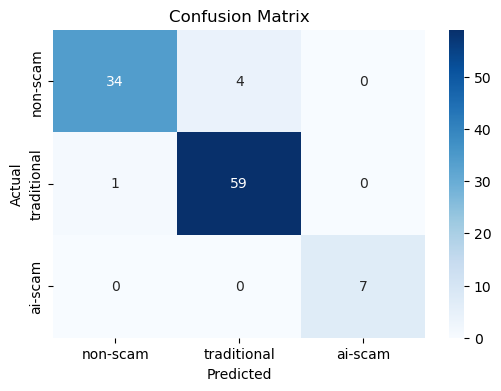

In [22]:
#evaluation
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# 1. predict
y_pred = clf.predict(X_test_tfidf)
# 2. report
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))
# 3. confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=["non-scam", "traditional", "ai-scam"],
            yticklabels=["non-scam", "traditional", "ai-scam"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
#Extract the top 15 feature words for each category
import numpy as np
feature_names = np.array(tfidf.get_feature_names_out())
coefs = clf.coef_
def top_terms_for_class(class_index, top_n=15):
    # Take the weight corresponding to this class
    coef = coefs[class_index]
    # The features of the top_n rank
    top_ids = np.argsort(coef)[-top_n:]
    return feature_names[top_ids][::-1]  # Arranged from largest to smallest

print("Top terms — non-scam (0):")
print(top_terms_for_class(0))

print("\nTop terms — traditional scam (1):")
print(top_terms_for_class(1))

print("\nTop terms — AI scam (2):")
print(top_terms_for_class(2))

Top terms — non-scam (0):
['step' 'your name' 'you' 'thank you' 'the' 'event' 'name' 'thank'
 'assistant' 'may' 'be' 'email' 'assist' 'good' 'for']

Top terms — traditional scam (1):
['we' 'security' 'official' 'proceed' 'we need' 'you provide' 'need to'
 'immediate' 'provide' 'goodbye' 'verify' 'and' 'need' 'over the'
 'details about']

Top terms — AI scam (2):
['uh' 'listen' 'listen uh' 'my' 'if' 'there' 'really' 'so' 'know' 'just'
 'they' 'uh uh' 'hey there' 'something' 'some']
